# Taller 02: Poda Alfa-Beta

**Inteligencia Artificial - ELP 8012 - Universidad del Norte**
Profesor: Eduardo Zurek, Ph.D.

Este notebook implementa un algoritmo de **poda alfa-beta genérico**, aplicable a
cualquier árbol de juego representado mediante listas anidadas de Python, por
ejemplo:

```python
[ [3, -5, 2], [-5, -7, 4], [-9, 6, -8] ]
```

donde cada lista representa un nodo interno (los hijos son sus elementos) y cada
número representa una hoja (el valor de utilidad terminal). La raíz siempre es
un nodo **MAX**; los niveles se alternan MAX / MIN a medida que se desciende.

El notebook incluye:

1. Una estructura de árbol construida a partir de listas anidadas (hasta 5
   niveles y 50 hojas).
2. El algoritmo de poda alfa-beta, que registra el valor óptimo, la secuencia
   de jugadas óptima y las ramas podadas.
3. Un generador aleatorio de árboles, parametrizado por número de niveles y
   número de hojas.
4. Una visualización gráfica del árbol que resalta la secuencia óptima de
   jugadas y marca las ramas podadas.

> **Cómo usarlo:** modifique la lista `ARBOL` en la **segunda celda de
> código** (justo después de la celda que importa las librerías) para
> configurar el árbol de entrada, y luego ejecute todas las celdas en orden
> (`Kernel > Restart & Run All`).


In [1]:
# Librerías utilizadas en todo el notebook
import math
import random

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

random.seed()  # semilla del sistema; puede fijarse un entero para reproducibilidad


## Árbol de entrada (configurable)

Edite la lista `ARBOL` a continuación para definir el árbol de juego que se
desea analizar. Debe ser una lista de Python anidada de hasta 5 niveles y
hasta 50 nodos hoja, con el mismo formato del ejemplo del enunciado.

In [2]:
# >>> ESTA ES LA CELDA CONFIGURABLE <<<
# Defina aquí el árbol de juego como una lista anidada de Python.
# Ejemplo tomado del enunciado del taller:
ARBOL = [[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]


## 1. Estructura genérica del árbol

Convertimos la lista anidada en un árbol de objetos `Nodo`. Un nodo es una
**hoja** si el elemento correspondiente de la lista es un número; es un
**nodo interno** si es a su vez una lista. Cada nodo interno alterna entre
jugador **MAX** (niveles pares, empezando en la raíz = nivel 0) y jugador
**MIN** (niveles impares), como es estándar en árboles de juego de suma
cero (minimax).

In [3]:
class Nodo:
    '''Nodo de un árbol de juego construido a partir de listas anidadas.'''

    __slots__ = (
        "id", "depth", "parent", "children", "is_leaf", "leaf_value",
        "value", "visited", "pruned", "best_child_id", "x", "y",
    )

    def __init__(self, id_, depth, parent, is_leaf, leaf_value=None):
        self.id = id_
        self.depth = depth
        self.parent = parent
        self.children = []
        self.is_leaf = is_leaf
        self.leaf_value = leaf_value
        self.value = None          # valor calculado por alfa-beta (None si fue podado)
        self.visited = False       # True si el algoritmo llegó a evaluarlo
        self.pruned = False        # True si fue descartado por la poda
        self.best_child_id = None  # hijo elegido (para reconstruir la secuencia óptima)
        self.x = None              # posición horizontal (para dibujar)
        self.y = None              # posición vertical (para dibujar)


def construir_arbol(lista_o_valor):
    '''Convierte una lista anidada de Python (o un número) en un árbol de
    objetos Nodo. La raíz corresponde siempre al primer nivel de la lista
    (nodo MAX).'''
    contador = {"n": 0}

    def _construir(elemento, depth, parent):
        nid = contador["n"]
        contador["n"] += 1
        if isinstance(elemento, list):
            nodo = Nodo(nid, depth, parent, is_leaf=False)
            nodo.children = [_construir(hijo, depth + 1, nodo) for hijo in elemento]
        else:
            nodo = Nodo(nid, depth, parent, is_leaf=True, leaf_value=elemento)
        return nodo

    return _construir(lista_o_valor, 0, None)


def contar_hojas(lista_o_valor):
    '''Cuenta cuántos nodos hoja tiene una lista anidada.'''
    if isinstance(lista_o_valor, list):
        return sum(contar_hojas(x) for x in lista_o_valor)
    return 1


def contar_niveles(lista_o_valor):
    '''Cuenta cuántos niveles (incluida la raíz y las hojas) tiene una lista anidada.'''
    if isinstance(lista_o_valor, list):
        return 1 + max((contar_niveles(x) for x in lista_o_valor), default=0)
    return 1


## 2. Algoritmo de poda alfa-beta

`poda_alfa_beta` recorre el árbol con minimax, manteniendo los valores
`alpha` (mejor valor garantizado para MAX) y `beta` (mejor valor garantizado
para MIN). Cuando `alpha >= beta` en un nodo, el resto de sus hijos (y todos
sus descendientes) se **podan**: no se visitan ni se evalúan, porque no
pueden cambiar la decisión óptima.

Durante el recorrido se registra en cada `Nodo`:

- `value`: el valor minimax calculado (o `None` si el nodo fue podado).
- `visited` / `pruned`: si el nodo fue evaluado o descartado.
- `best_child_id`: el hijo que determinó el valor del nodo, lo que permite
  reconstruir la **secuencia óptima de jugadas** (variación principal) desde
  la raíz hasta una hoja.

In [4]:
def _marcar_podado(nodo):
    '''Marca recursivamente un nodo y todo su subárbol como podado.'''
    nodo.pruned = True
    nodo.visited = False
    for hijo in nodo.children:
        _marcar_podado(hijo)


def poda_alfa_beta(nodo, alpha=-math.inf, beta=math.inf, es_maximizador=True):
    '''Ejecuta minimax con poda alfa-beta sobre el árbol genérico.

    Devuelve el valor minimax del nodo y deja registrado en cada Nodo del
    árbol su valor, si fue visitado/podado y cuál fue su mejor hijo.
    '''
    nodo.visited = True
    nodo.pruned = False

    if nodo.is_leaf:
        nodo.value = nodo.leaf_value
        return nodo.value

    if es_maximizador:
        mejor = -math.inf
        for i, hijo in enumerate(nodo.children):
            v = poda_alfa_beta(hijo, alpha, beta, False)
            if v > mejor:
                mejor = v
                nodo.best_child_id = hijo.id
            alpha = max(alpha, mejor)
            if alpha >= beta:               # poda beta
                for hijo_podado in nodo.children[i + 1:]:
                    _marcar_podado(hijo_podado)
                break
    else:
        mejor = math.inf
        for i, hijo in enumerate(nodo.children):
            v = poda_alfa_beta(hijo, alpha, beta, True)
            if v < mejor:
                mejor = v
                nodo.best_child_id = hijo.id
            beta = min(beta, mejor)
            if alpha >= beta:               # poda alfa
                for hijo_podado in nodo.children[i + 1:]:
                    _marcar_podado(hijo_podado)
                break

    nodo.value = mejor
    return mejor


def secuencia_optima(raiz):
    '''Devuelve la lista de nodos que forman la secuencia óptima de jugadas
    (variación principal) desde la raíz hasta la hoja elegida.'''
    camino = [raiz]
    actual = raiz
    while not actual.is_leaf:
        siguiente = next(h for h in actual.children if h.id == actual.best_child_id)
        camino.append(siguiente)
        actual = siguiente
    return camino


## 3. Generador aleatorio de árboles

`generar_arbol_aleatorio(niveles, num_hojas, ...)` construye una lista
anidada aleatoria con **exactamente** el número de niveles y el número de
hojas indicados (respetando los límites del enunciado: hasta 5 niveles y
hasta 50 hojas), repartiendo las hojas al azar entre los nodos internos de
cada nivel (cada nodo interno tiene entre 1 y `max_hijos` hijos).

In [5]:
def _repartir(n, k):
    '''Reparte el entero n en k partes enteras positivas, al azar
    (composición aleatoria de n en k partes).'''
    k = max(1, min(k, n))
    if k == 1:
        return [n]
    cortes = sorted(random.sample(range(1, n), k - 1))
    partes, anterior = [], 0
    for c in cortes + [n]:
        partes.append(c - anterior)
        anterior = c
    return partes


def generar_arbol_aleatorio(niveles, num_hojas, rango_valores=(-10, 10), max_hijos=4, semilla=None):
    '''Genera aleatoriamente una lista anidada de Python que representa un
    árbol de juego con exactamente `niveles` niveles (incluyendo la raíz y
    el nivel de las hojas) y exactamente `num_hojas` nodos hoja.

    Parámetros
    ----------
    niveles : int
        Número de niveles del árbol, incluyendo la raíz y las hojas
        (2 <= niveles <= 5 según el enunciado).
    num_hojas : int
        Número total de nodos hoja del árbol (1 <= num_hojas <= 50).
    rango_valores : tuple(int, int)
        Rango (mínimo, máximo) para los valores aleatorios de las hojas.
    max_hijos : int
        Número máximo de hijos por nodo interno.
    semilla : int, opcional
        Semilla para `random`, útil para obtener resultados reproducibles.
    '''
    if semilla is not None:
        random.seed(semilla)
    if niveles < 2:
        raise ValueError("niveles debe ser al menos 2 (una raíz y sus hojas)")
    if num_hojas < 1:
        raise ValueError("num_hojas debe ser al menos 1")

    def _construir(profundidad_restante, hojas_necesarias):
        # profundidad_restante = número de aristas que faltan para llegar a las hojas
        if profundidad_restante == 1:
            # este nodo es una lista cuyos hijos son directamente las hojas
            return [random.randint(*rango_valores) for _ in range(hojas_necesarias)]
        k = max(1, min(max_hijos, hojas_necesarias))
        partes = _repartir(hojas_necesarias, k)
        return [_construir(profundidad_restante - 1, p) for p in partes]

    return _construir(niveles - 1, num_hojas)


## 4. Visualización

`dibujar_arbol` dibuja el árbol con `matplotlib`:

- **Azul** = nodo MAX, **rojo** = nodo MIN, **gris** = hoja.
- La **secuencia óptima de jugadas** se resalta con una línea y borde
  dorados.
- Las **ramas podadas** se dibujan atenuadas, con línea punteada y una
  marca en forma de "✕" sobre la arista podada.

In [6]:
def _asignar_posiciones(nodo, contador_hojas):
    '''Asigna coordenadas (x, y) a cada nodo para el dibujo: x según el
    orden de las hojas (de izquierda a derecha) y promedio de los hijos
    para los nodos internos; y según la profundidad.'''
    if nodo.is_leaf:
        nodo.x = contador_hojas["n"]
        contador_hojas["n"] += 1
    else:
        for h in nodo.children:
            _asignar_posiciones(h, contador_hojas)
        xs = [h.x for h in nodo.children]
        nodo.x = sum(xs) / len(xs)
    nodo.y = -nodo.depth


def _recolectar(nodo, nodos, edges):
    nodos.append(nodo)
    for h in nodo.children:
        edges.append((nodo, h))
        _recolectar(h, nodos, edges)


COLOR_MAX = "#2f6fa8"      # azul: nodos donde juega el maximizador
COLOR_MIN = "#b8442f"      # rojo: nodos donde juega el minimizador
COLOR_HOJA = "#6b6b6b"     # gris: hojas
COLOR_PODADO = "#c9c9c9"   # gris claro: ramas/nodos podados
COLOR_OPTIMO = "#e0a72f"   # dorado: secuencia óptima


def dibujar_arbol(raiz, titulo=None, figsize=None, ax=None):
    '''Dibuja el árbol de juego mostrando el resultado de la poda alfa-beta:
    valores calculados, la secuencia óptima de jugadas y las ramas podadas.
    Debe llamarse después de `poda_alfa_beta(raiz)`.
    '''
    _asignar_posiciones(raiz, {"n": 0})

    nodos, edges = [], []
    _recolectar(raiz, nodos, edges)

    n_hojas = sum(1 for n in nodos if n.is_leaf)
    max_depth = max(n.depth for n in nodos)

    if figsize is None:
        figsize = (max(8, n_hojas * 0.9), max(4.5, (max_depth + 1) * 1.6))

    creado_fig = ax is None
    if creado_fig:
        fig, ax = plt.subplots(figsize=figsize)

    camino_optimo = secuencia_optima(raiz)
    ids_camino = {n.id for n in camino_optimo}
    edges_camino = {(camino_optimo[i].id, camino_optimo[i + 1].id) for i in range(len(camino_optimo) - 1)}

    # --- Aristas ---
    for padre, hijo in edges:
        en_camino = (padre.id, hijo.id) in edges_camino
        if hijo.pruned:
            ax.plot([padre.x, hijo.x], [padre.y, hijo.y], color=COLOR_PODADO,
                     linestyle="--", linewidth=1.6, zorder=1)
        elif en_camino:
            ax.plot([padre.x, hijo.x], [padre.y, hijo.y], color=COLOR_OPTIMO,
                     linewidth=3.2, zorder=3, solid_capstyle="round")
        else:
            ax.plot([padre.x, hijo.x], [padre.y, hijo.y], color="#444444",
                     linewidth=1.2, zorder=2)

    # --- Marca sobre la arista podada ---
    for padre, hijo in edges:
        if hijo.pruned:
            mx, my = (padre.x + hijo.x) / 2, (padre.y + hijo.y) / 2
            ax.plot(mx, my, marker="x", color="#b8442f", markersize=10, mew=2.2, zorder=4)

    # --- Nodos (tamaño en puntos, no en unidades de datos -> siempre circulares) ---
    marker_size = 620 if n_hojas <= 25 else max(260, 620 - (n_hojas - 25) * 8)
    for nodo in nodos:
        en_camino = nodo.id in ids_camino
        if nodo.pruned:
            color, alpha = COLOR_PODADO, 0.55
        elif nodo.is_leaf:
            color, alpha = COLOR_HOJA, 1.0
        elif nodo.depth % 2 == 0:
            color, alpha = COLOR_MAX, 1.0
        else:
            color, alpha = COLOR_MIN, 1.0

        borde = COLOR_OPTIMO if en_camino else "black"
        grosor_borde = 3.0 if en_camino else 1.0

        ax.scatter([nodo.x], [nodo.y], s=marker_size, facecolor=color, edgecolor=borde,
                    linewidth=grosor_borde, alpha=alpha, zorder=5)

        if nodo.pruned:
            etiqueta = ""
        elif nodo.is_leaf:
            etiqueta = str(nodo.leaf_value)
        else:
            etiqueta = str(nodo.value)

        ax.text(nodo.x, nodo.y, etiqueta, ha="center", va="center",
                 fontsize=8.5, fontweight="bold", color="white" if not nodo.pruned else "#666666", zorder=6)

    # --- Etiquetas de nivel (MAX / MIN / HOJAS) ---
    for d in range(max_depth + 1):
        xs_nivel = [n.x for n in nodos if n.depth == d]
        if not xs_nivel:
            continue
        etiqueta_nivel = "HOJAS" if d == max_depth else ("MAX" if d % 2 == 0 else "MIN")
        ax.text(min(xs_nivel) - 0.9, -d, etiqueta_nivel, ha="right", va="center",
                 fontsize=9, fontweight="bold", color="#333333")

    ax.set_xlim(min(n.x for n in nodos) - 1.6, max(n.x for n in nodos) + 0.6)
    ax.set_ylim(-max_depth - 0.6, 0.6)
    ax.axis("off")

    if titulo is None:
        titulo = f"Poda Alfa-Beta — valor óptimo en la raíz = {raiz.value}"
    ax.set_title(titulo, fontsize=12, fontweight="bold")

    leyenda = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_MAX, markersize=10, label="Nodo MAX"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_MIN, markersize=10, label="Nodo MIN"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_HOJA, markersize=10, label="Hoja"),
        Line2D([0], [0], color=COLOR_OPTIMO, linewidth=3, label="Secuencia óptima"),
        Line2D([0], [0], color=COLOR_PODADO, linewidth=2, linestyle="--", label="Rama podada"),
    ]
    ax.legend(handles=leyenda, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=8)

    if creado_fig:
        fig.tight_layout()
        return fig, ax
    return ax


## 5. Ejecución con el árbol configurado (celda 2)

A continuación se construye el árbol a partir de la lista `ARBOL` definida
en la celda 2, se ejecuta la poda alfa-beta y se muestra el resultado:
el valor óptimo, la secuencia óptima de jugadas y la figura con las ramas
podadas.

Niveles del árbol : 3
Nodos hoja        : 9
Valor óptimo (raíz): -5
Secuencia óptima de jugadas (valores por nivel): [-5, -5, -5]


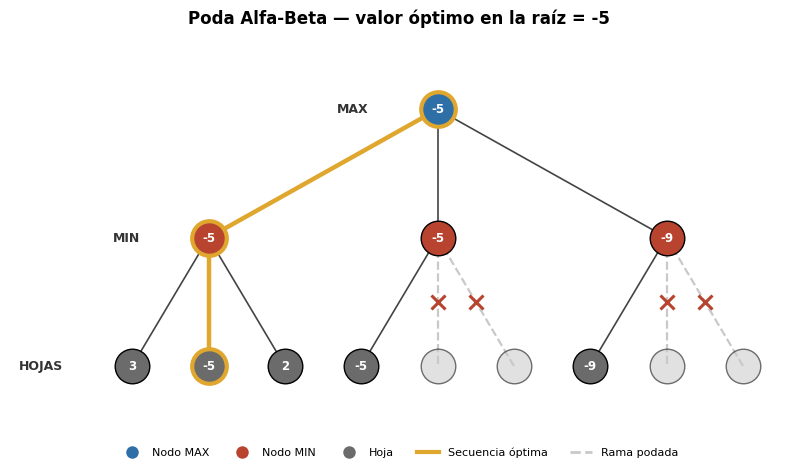

In [7]:
raiz = construir_arbol(ARBOL)
valor_optimo = poda_alfa_beta(raiz)

camino = secuencia_optima(raiz)
secuencia_valores = [n.leaf_value if n.is_leaf else n.value for n in camino]

print(f"Niveles del árbol : {contar_niveles(ARBOL)}")
print(f"Nodos hoja        : {contar_hojas(ARBOL)}")
print(f"Valor óptimo (raíz): {valor_optimo}")
print(f"Secuencia óptima de jugadas (valores por nivel): {secuencia_valores}")

fig, ax = dibujar_arbol(raiz)
plt.show()


## 6. Ejemplo con un árbol generado aleatoriamente

Aquí se muestra el uso del generador aleatorio: se especifica el número de
niveles y el número de hojas deseado, y se repite el mismo proceso de poda
alfa-beta y visualización. Cambie `NIVELES_ALEATORIO` y `HOJAS_ALEATORIO`
para experimentar (máximo 5 niveles y 50 hojas, según el enunciado).

Lista generada: [[[6, 2], [6, 4], [-3], [10, -9]], [[-2]], [[5], [8], [-6, 6], [7]], [[-1], [-4], [3]]]
Valor óptimo (raíz): 5


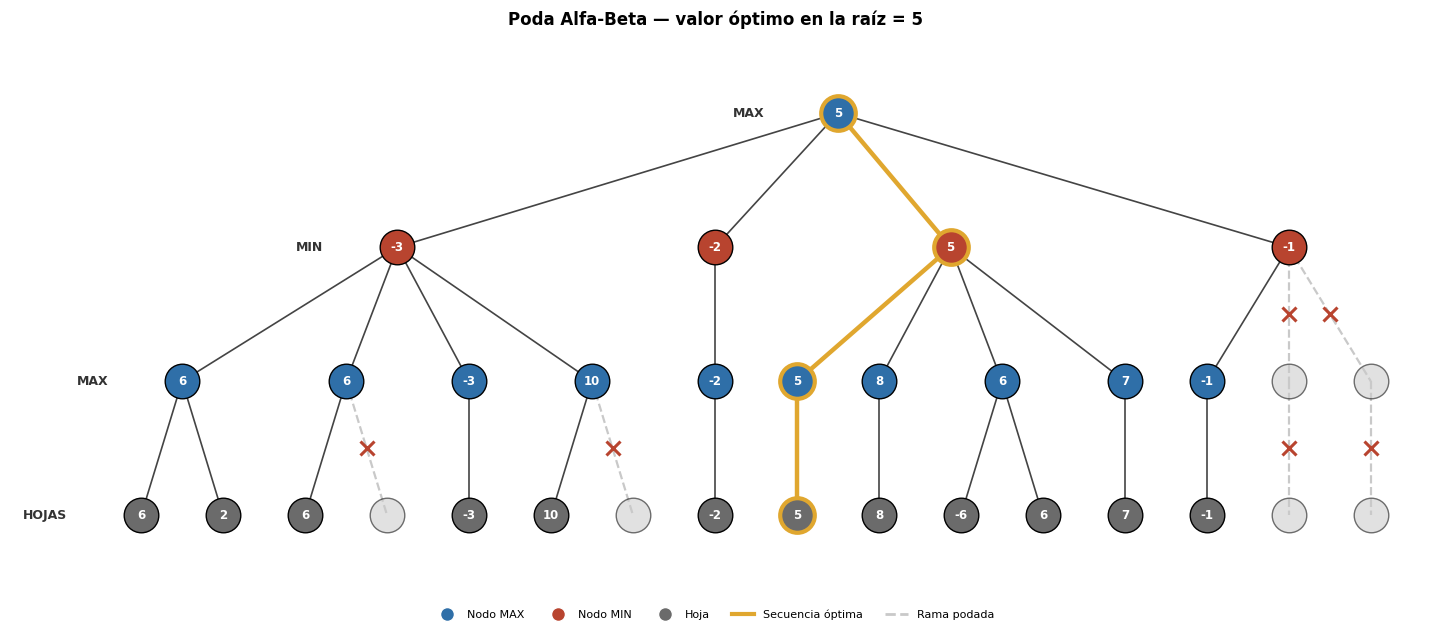

In [8]:
NIVELES_ALEATORIO = 4
HOJAS_ALEATORIO = 16
SEMILLA_ALEATORIA = None  # use un entero (p. ej. 42) para reproducir el mismo árbol

arbol_aleatorio = generar_arbol_aleatorio(
    niveles=NIVELES_ALEATORIO,
    num_hojas=HOJAS_ALEATORIO,
    semilla=SEMILLA_ALEATORIA,
)
print("Lista generada:", arbol_aleatorio)

raiz_r = construir_arbol(arbol_aleatorio)
valor_r = poda_alfa_beta(raiz_r)
print(f"Valor óptimo (raíz): {valor_r}")

fig_r, ax_r = dibujar_arbol(raiz_r)
plt.show()


## 7. Prueba con un árbol grande (5 niveles, 50 hojas)

Verificación de que la implementación funciona en el límite indicado por el
enunciado: hasta 5 niveles y hasta 50 nodos hoja.

Niveles: 5  | Hojas: 50
Valor óptimo (raíz): 5


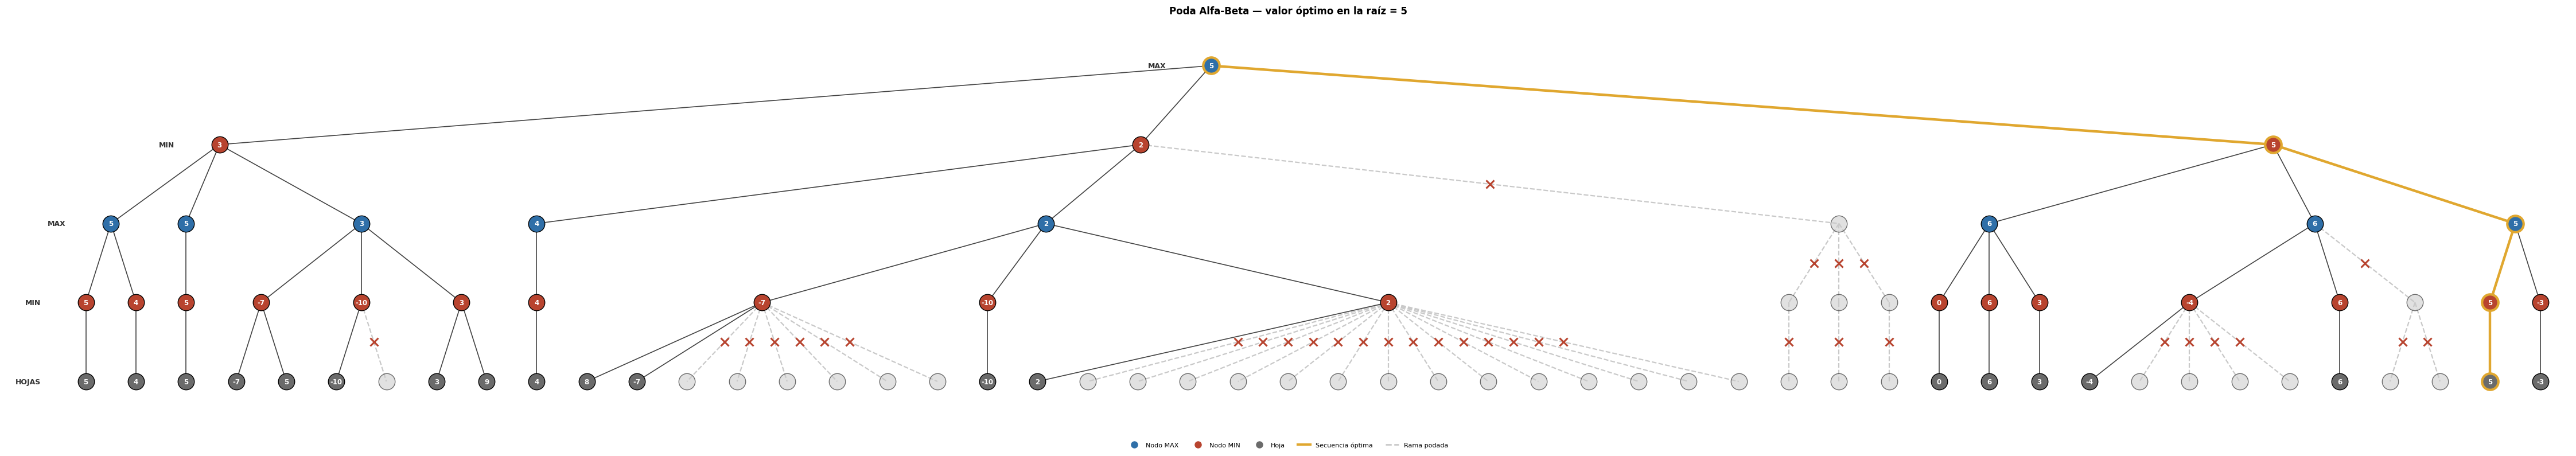

In [9]:
arbol_grande = generar_arbol_aleatorio(niveles=5, num_hojas=50, max_hijos=3, semilla=1)
print("Niveles:", contar_niveles(arbol_grande), " | Hojas:", contar_hojas(arbol_grande))

raiz_g = construir_arbol(arbol_grande)
valor_g = poda_alfa_beta(raiz_g)
print("Valor óptimo (raíz):", valor_g)

fig_g, ax_g = dibujar_arbol(raiz_g)
plt.show()
